# Beispiel für einen VAE (Variational Autoencoder)

<b>Es handelt sich dabei um einen convolutional VAE (ein VAE mit CNN im Encoder-Teil) auf der Basis des MNIST-Datensatzes</b>

Der folgende Block importiert die notwendigen Bibliotheken für die Implementierung des VAE. Keras und TensorFlow werden für die Erstellung und das Training des Modells verwendet, während NumPy für die Datenmanipulation und Matplotlib für die Visualisierung benötigt werden. Der Code gibt außerdem die installierte Version von TensorFlow aus, um sicherzustellen, dass eine kompatible Version verwendet wird.

In [ ]:
import keras
import numpy as np
import tensorflow as tf # getestet mit Version 2.17.0
from tensorflow import keras
from keras import layers, models
from keras.datasets import mnist
import matplotlib.pyplot as plt
print(tf.__version__)

2.17.0


Als nächstes wird zuerst eine eigene Sampling-Schicht definiert. Diese Schicht ist entscheidend für den VAE, da sie es dem Modell ermöglicht, Zufälligkeit in den Prozess einzuführen, was für die Generierung realistischer Datenproben notwendig ist. Die Sampling-Schicht verwendet z_mean und z_log_var, um eine neue Variable z zu berechnen, die aus einer Normalverteilung gezogen wird.

Der zweite Teil des Blocks erstellt das Encoder-Modell des VAE. Der Encoder komprimiert die Eingabedaten (encoder_inputs) in eine niedrigdimensionale latente Repräsentation (z_mean und z_log_var). Diese latenten Variablen sind Parameter, die den zugrunde liegenden Verteilungsraum beschreiben, aus dem neue Datenpunkte generiert werden können.

In [ ]:
# Definiere die Sampling-Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Erstelle das Encoder-Modell
latent_dim = 2  # Beispielwert für die Dimension des latenten Raums
encoder_inputs = keras.Input(shape=(28, 28, 1))  # Beispiel für Eingabeform
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(64, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Verwende die Sampling-Schicht
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 784)               │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │          50,240 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │             130 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │             130 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sampling (Sampling)           │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 50,500 (197.27 KB)

 Trainable params: 50,500 (197.27 KB)

 Non-trainable params: 0 (0.00 B)

Der nächste Code-Block erstellt das Decoder-Modell des VAE. Der Decoder nimmt die latente Variable z als Eingabe und versucht, die ursprünglichen Eingabedaten zu rekonstruieren. Hierbei wird eine Reihe von Dense- und Conv2DTranspose-Schichten verwendet, um die Daten schrittweise in die ursprüngliche Eingabegröße zurückzuführen. Die letzte Schicht verwendet eine sigmoid-Aktivierungsfunktion, um sicherzustellen, dass die Ausgabe-Werte im Bereich [0, 1] liegen, passend zu den normalisierten Eingabedaten.

In [ ]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3136)                │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 28, 28, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Im nächsten Abschnitt wird das vollständige VAE-Modell durch die Kombination des Encoders und Decoders definiert. Der VAE ist ein neuronales Netzwerk, das darauf trainiert wird, eine niedrige, latente Darstellung der Eingabedaten zu lernen und diese dann zu rekonstruierten Ausgaben zu dekomprimieren.

Die Loss-Funktion des VAEs setzt sich aus zwei Teilen zusammen:
* Rekonstruktionsverlust: Misst die Differenz zwischen den Originaldaten und den rekonstruierten Daten, typischerweise durch binäre Kreuzentropie, da es sich um pixelweise Klassifikationen handelt (Schwarz/Weiß).
* Kullback-Leibler (KL) Divergenz: Diese Regularisierungskomponente misst den Unterschied zwischen der Verteilung der latenten Variablen und einer Standardnormalverteilung. Sie zwingt das Modell, eine sinnvolle latente Raumstruktur zu lernen.

Die Kombination dieser beiden Verluste sorgt dafür, dass das VAE sowohl genaue Rekonstruktionen der Eingabedaten erzeugt als auch eine latente Repräsentation lernt, die sinnvoll für die Generierung neuer Daten ist.

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

Als nächstes lädt man das MNIST-Datenset, das häufig für die Bildverarbeitung und maschinelles Lernen verwendet wird. Das Dataset besteht aus handgeschriebenen Ziffern, die in Graustufenbildern von 28x28 Pixeln dargestellt sind. Die Daten werden auf den Bereich [0, 1] normalisiert, um die Leistung des Modells zu verbessern.

In [ ]:
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([X_train, X_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

Das Modell wird nun mit den Trainingsdaten für 30 Epochen und einer Batch-Größe von 128 trainiert. Hierbei wird das Modell trainiert, die Eingabebilder zu rekonstruieren, was bedeutet, dass sowohl die Eingabedaten (x_train) als auch die Ausgabedaten (x_train) dieselben sind.

In [ ]:
vae.fit(mnist_digits, epochs=30, batch_size=128)
# Laufzeit ca. 20 min (ohne GPU)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - kl_loss: 3.1257 - loss: 243.3468 - reconstruction_loss: 240.2211
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - kl_loss: 5.2417 - loss: 164.4753 - reconstruction_loss: 159.2335
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - kl_loss: 5.7640 - loss: 158.2511 - reconstruction_loss: 152.4871
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - kl_loss: 6.0245 - loss: 155.1241 - reconstruction_loss: 149.0995
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step - kl_loss: 6.1669 - loss: 153.6304 - reconstruction_loss: 147.4635
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - kl_loss: 6.2962 - loss: 152.6788 - reconstruction_loss: 146.3826
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step - kl_loss: 6.3533 - loss: 151.9982 - reconstruction_loss: 145.6449
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - kl_loss: 6.4034 - loss: 150.8661 - reconstruction_loss: 144.4626
Epoch 9/30
547/547 ━━━━━━━━━━━━━

Der kommemde Abschnitt enthält eine Funktion zur Visualisierung des latenten Raums des VAEs. Der latente Raum ist ein niedrigdimensionaler Raum, in dem ähnliche Datenpunkte nahe beieinander liegen. Diese Visualisierung zeigt, wie der VAE den latenten Raum verwendet, um verschiedene Eingabebilder zu erzeugen.

Die Funktion 'plot_latent_space' erstellt ein Gitter von Bildern, die durch Sampling verschiedener Punkte im latenten Raum erzeugt werden. Die Punkte sind so angeordnet, dass ähnliche Bilder nebeneinander liegen. Dies zeigt die Struktur des latenten Raums und demonstriert, wie gut der VAE in der Lage ist, eine kontinuierliche, glatte Darstellung der Daten zu lernen.

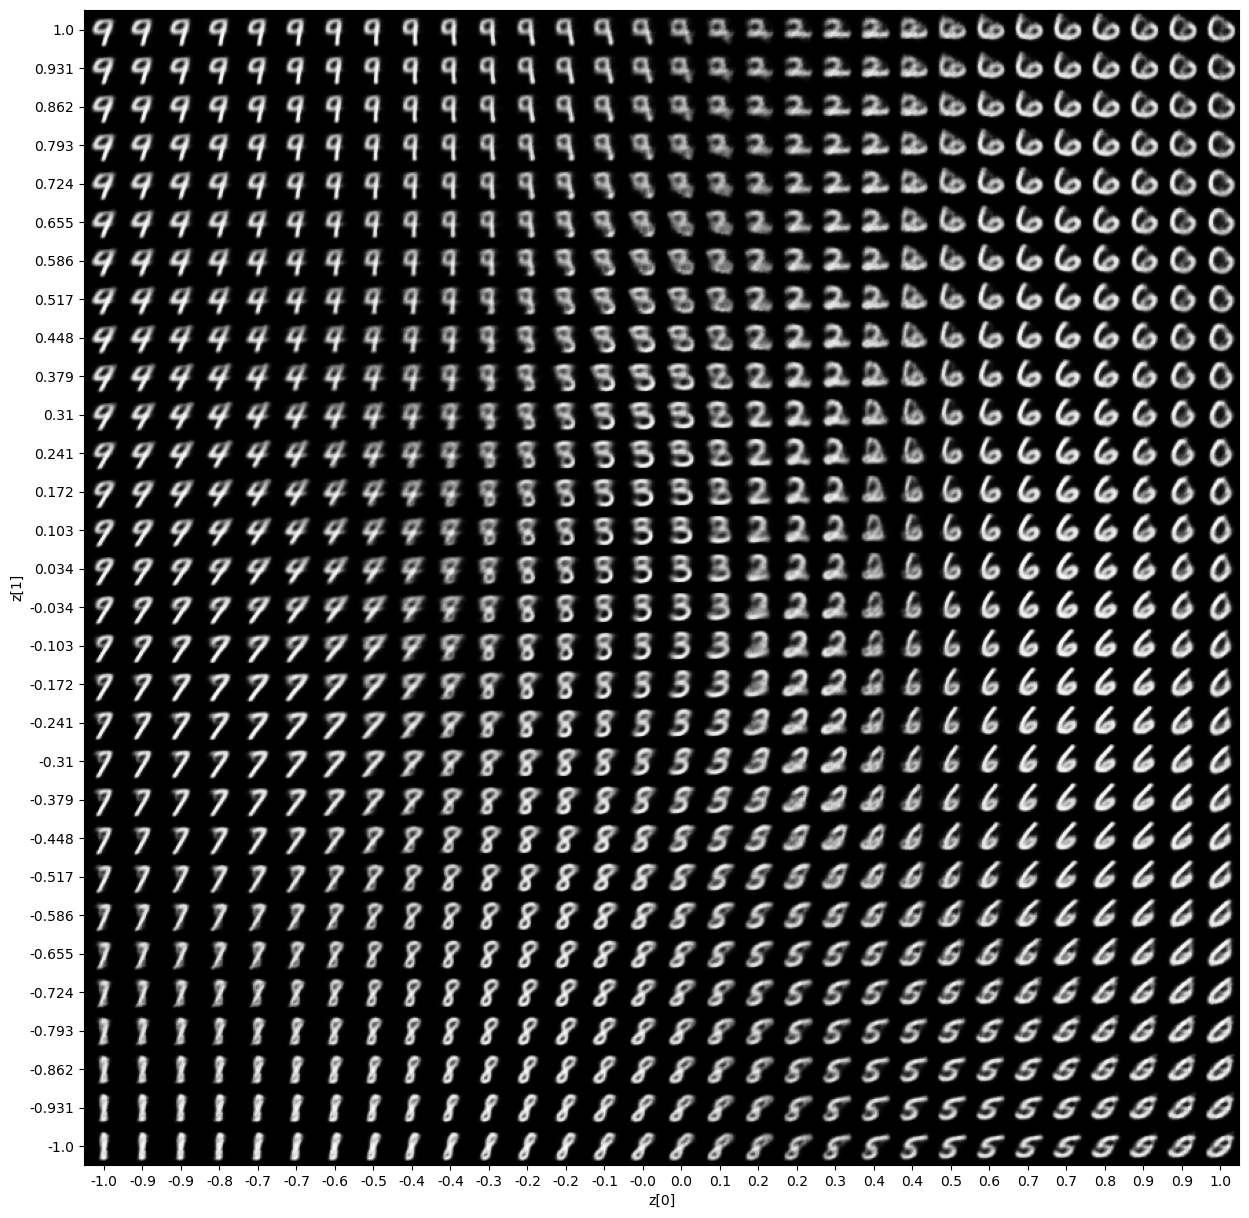

In [ ]:
def plot_latent_space(vae, n=30, figsize=15):
    # display a n*n 2D manifold of digits
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 3))
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(vae)

In nächsten Block wird eine Funktion definiert, die die Verteilung der verschiedenen Klassen (Ziffern von 0 bis 9) im latenten Raum des Variational Autoencoders (VAE) visualisiert.

Die Funktion plot_label_clusters erstellt ein 2D-Scatter-Plot, das die latenten Repräsentationen der Eingabedatenpunkte im latenten Raum darstellt.
* Jeder Punkt im Scatter-Plot entspricht einer Eingabedatenprobe (ein Bild einer Ziffer), die durch den Encoder des VAEs auf den latenten Raum projiziert wurde.
* z_mean wird berechnet, indem die Eingabedaten durch den Encoder des VAEs geführt werden. z_mean repräsentiert die Mittelwerte der latenten Verteilungen für jedes Eingabedatum.
* Die Streudiagramm (scatter) Funktion von Matplotlib zeigt diese Mittelwerte z_mean auf einer 2D-Karte an, wobei die Farbe der Punkte den zugehörigen Ziffernklassen entspricht (von 0 bis 9). Die Achsen des Diagramms entsprechen den beiden Dimensionen des latenten Raums (z[0] und z[1]).

Diese Visualisierung ist wichtig, weil sie zeigt, wie gut der VAE die Struktur der Daten im latenten Raum erlernt hat. Wenn der VAE gut trainiert ist, sollten ähnliche Ziffern im latenten Raum nahe beieinander gruppiert sein. Das bedeutet, dass der latente Raum eine sinnvolle Repräsentation der Daten gelernt hat, in der verschiedene Klassen von Datenpunkten (z.B. die verschiedenen Ziffern) in unterschiedliche Cluster projiziert werden.

Durch die Betrachtung der Cluster können wir sehen, ob der VAE gelernt hat, die Ziffern korrekt zu unterscheiden. Überlappende Cluster könnten darauf hinweisen, dass der VAE Schwierigkeiten hat, zwischen bestimmten Ziffern zu unterscheiden, während gut getrennte Cluster darauf hinweisen, dass der VAE die Daten gut versteht.

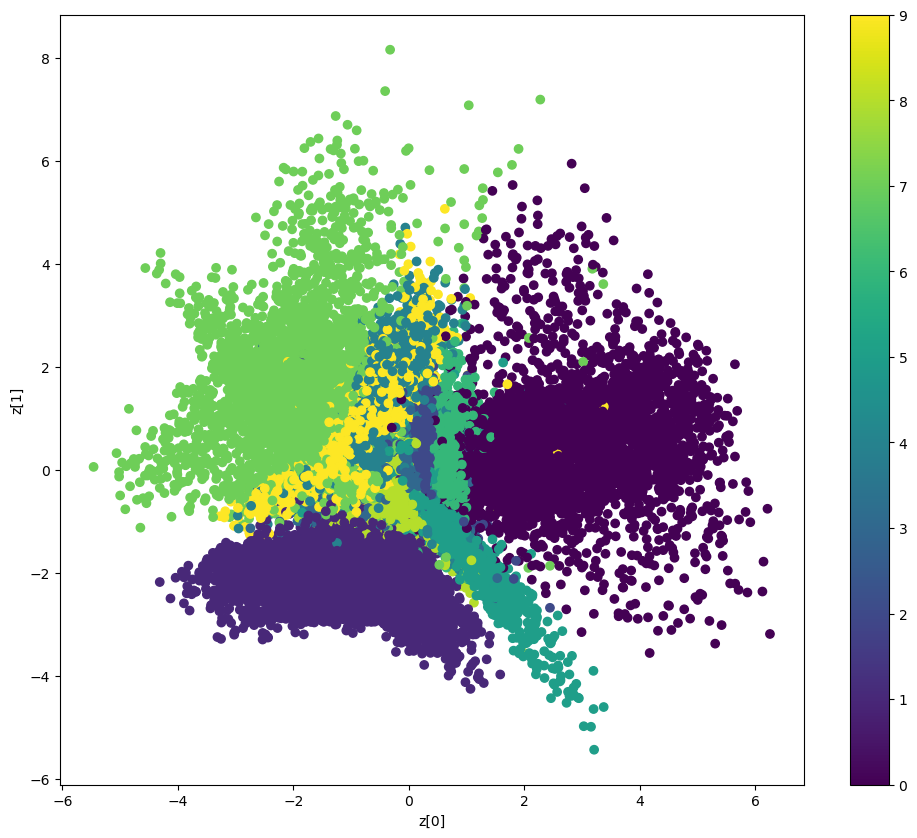

In [ ]:
def plot_label_clusters(vae, data, labels):
    # display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = vae.encoder.predict(data, verbose=0)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()

(X_train, Y_train), _ = keras.datasets.mnist.load_data()
X_train = np.expand_dims(X_train, -1).astype("float32") / 255

plot_label_clusters(vae, X_train, Y_train)

Die zwei Blöcke zum Schluss dienen der Visualisierung der neuen Bilder.

Dieser Block enthält eine Funktion, die neue Bilder generiert, indem sie zufällige Punkte aus dem latenten Raum zieht. Diese Punkte werden durch den Decoder geführt, um neue Bilder zu erzeugen. Die erzeugten Bilder zeigen, wie der VAE neue Datenpunkte aus der erlernten Verteilung generieren kann. Dies demonstriert die Fähigkeit des Modells, nicht nur vorhandene Daten zu rekonstruieren, sondern auch völlig neue Daten zu erzeugen, die realistisch erscheinen und zur gleichen Datenverteilung gehören.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


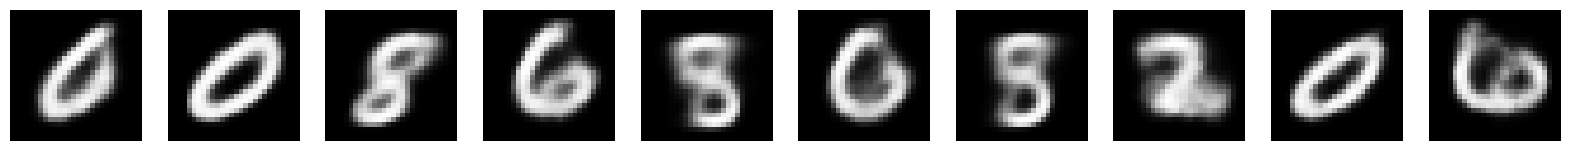

In [ ]:
# Generiere neue Bilder aus dem latenten Raum
def generate_images_from_latent_space(decoder, n=10):
    figure = plt.figure(figsize=(20, 4))
    for i in range(n):
        ax = figure.add_subplot(1, n, i + 1)
        z_sample = np.array([[np.random.normal(), np.random.normal()]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(28, 28)
        ax.imshow(digit, cmap='Greys_r')
        ax.axis('off')
    plt.show()

generate_images_from_latent_space(vae.decoder)